# 01 — The market problem: where battery revenue actually lives

**Audience:** energy/BESS decision-makers and AI-governance reviewers.
**Data:** ERCOT settlement point prices at **HB_HOUSTON**, Jan 01 – Jun 29, 2024 (4,343 hours), assembled by `forecast_to_dispatch.data.ingest` from ERCOT's public historical archives (day-ahead SPP, real-time 15-minute SPP averaged to hourly, and day-ahead ancillary-service clearing prices).

## Why this notebook exists

A grid-scale battery is not paid for average prices — it is paid for **spreads** (buy low, sell high) and for **scarcity** (the rare hours when real-time prices spike toward the offer cap). Before trusting any forecasting model, we establish four facts about this market, each with a figure:

1. Revenue concentrates in a tiny fraction of hours (*price duration curve*).
2. Those hours cluster in a predictable evening window (*price heatmap*).
3. The day-ahead vs real-time spread — the arbitrage product — is fat-tailed in both directions (*spread distribution*).
4. Scarcity arrives in episodic bursts, not on a schedule (*scarcity calendar*).

These four facts define the job of the rest of the system: **forecast the distribution of prices well enough to be positioned before the tail events arrive** — and prove it honestly.

In [1]:
import pandas as pd

from forecast_to_dispatch.config import load_config, resolve_path
from forecast_to_dispatch.viz.style import apply_style
from forecast_to_dispatch.viz import eda

config = load_config()
apply_style()

panel = pd.read_parquet(resolve_path(config, "processed") / "ercot_prices.parquet")
print(f"{len(panel):,} hourly intervals, {panel.index.min()} .. {panel.index.max()}")
panel.head()

4,343 hourly intervals, 2024-01-01 00:00:00-06:00 .. 2024-06-29 23:00:00-05:00


,dam_price,rtm_price,dart_spread,regup,regdn,rrs,nspin,ecrs
interval_start,,,,,,,,
2024-01-01 00:00:00-06:00,15.84,13.8800,1.9600,1.49,1.51,1.00,0.94,0.10
2024-01-01 01:00:00-06:00,16.84,15.9775,0.8625,1.47,1.25,1.00,0.94,0.11
2024-01-01 02:00:00-06:00,16.78,16.9950,-0.2150,1.80,1.25,1.00,1.23,0.12
2024-01-01 03:00:00-06:00,17.39,17.9525,-0.5625,1.60,1.25,1.00,1.23,0.13
2024-01-01 04:00:00-06:00,19.01,20.6575,-1.6475,2.00,1.25,1.01,1.23,0.14


## The dataset at a glance

Each row is one hour at the HB_HOUSTON trading hub with three kinds of prices, aligned on one timezone-aware hourly index by the ingest module (which **fails loudly on any gap** — a silent hole here would corrupt every downstream revenue number):

- **`dam_price`** — Day-Ahead Market settlement point price (\$/MWh), the price you lock in a day in advance.
- **`rtm_price`** — Real-Time Market price (\$/MWh), averaged from four 15-minute settlement intervals. This is where scarcity shows up.
- **`dart_spread`** = DAM − RTM. Positive → day-ahead traded at a premium; negative → real time spiked above the forward expectation.
- **`regup`, `regdn`, `rrs`, `nspin`, `ecrs`** — clearing prices for the five ERCOT ancillary services (\$/MW per hour of standby). Under **RTC+B** a battery is co-optimized across energy *and* these reserve products, which is where revenue stacking comes from.

In [2]:
summary = panel.describe().T[["mean", "std", "min", "50%", "max"]].round(2)
summary

,mean,std,min,50%,max
dam_price,30.64,79.97,-0.02,18.50,2215.08
rtm_price,27.31,76.06,-31.84,18.63,3049.48
dart_spread,3.32,63.10,-1151.34,1.10,1477.65
regup,8.16,48.10,0.72,1.98,1007.00
regdn,4.71,32.23,0.01,1.97,1455.29
rrs,7.78,55.43,0.80,1.50,1458.75
nspin,10.25,66.92,0.07,1.50,2150.00
ecrs,12.73,76.18,0.03,1.75,2086.26


**Reading the summary:** the mean real-time price is a modest \$27/MWh, but the maximum hit **\$3,049/MWh** — a 112× multiple. The median ancillary clearing prices are single-digit dollars, yet they apply to *capacity held in reserve*, not energy delivered — a battery can often earn them while keeping its charge for the evening. That asymmetry (long calm, extreme spikes) is exactly why this system forecasts **quantiles**, not point estimates: the P50 will never see a spike coming, but a well-calibrated P95 can.

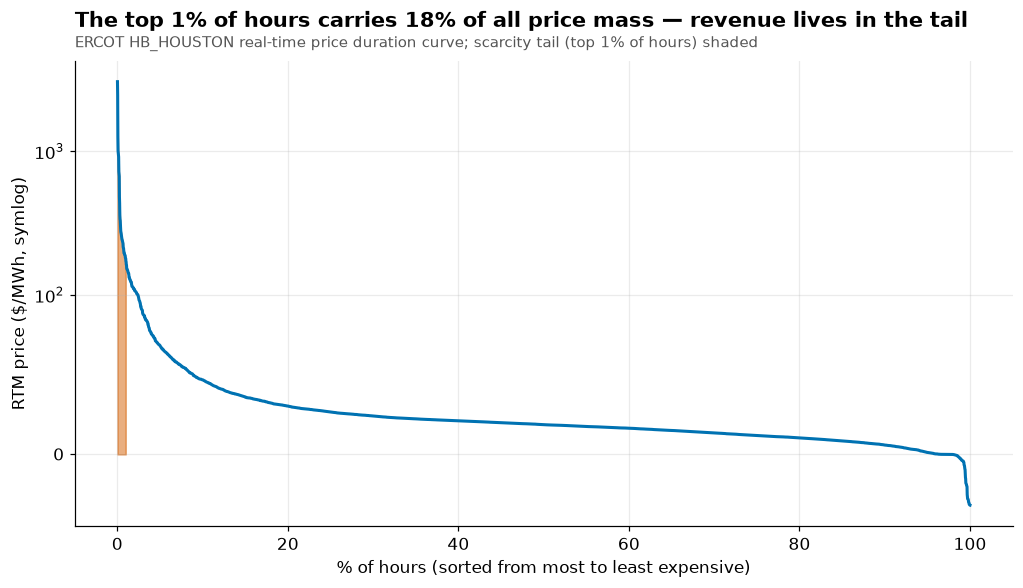

In [3]:
fig = eda.fig15_price_duration_curve(panel)

### Interpretation — fig15

The top **1%** of hours carries **18%** of the entire price mass of the half-year; the curve collapses from \$3,049/MWh to double digits within the first few percent of hours. For an operator this means annual revenue is decided in roughly **43 hours per half-year**, and missing even a couple of spike evenings materially dents the P&L. *Business consequence:* the forecasting problem that matters is not average accuracy (RMSE) but **tail positioning** — which is why Phase 3 evaluates scarcity recall and interval calibration, not just point error.

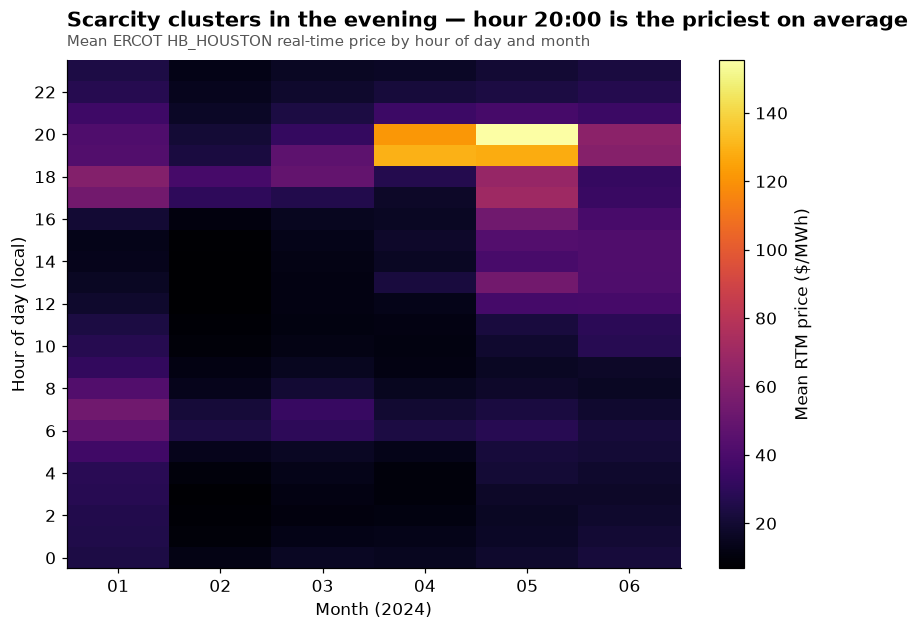

In [4]:
fig = eda.fig16_hourly_price_heatmap(panel)

### Interpretation — fig16

Expensive hours are not scattered randomly: they concentrate around **hour 20:00 local**, the early-evening net-load peak when solar output fades while demand is still high, and intensify into the summer months. This regularity is the battery's friend — a 2-hour battery must simply be **fully charged before this window opens**. *Business consequence:* the dispatch optimizer (Phase 4) should show systematic charging in the cheap overnight/midday trough and discharging into this window; fig21's SOC heatmap will verify exactly that behavior across the whole backtest.

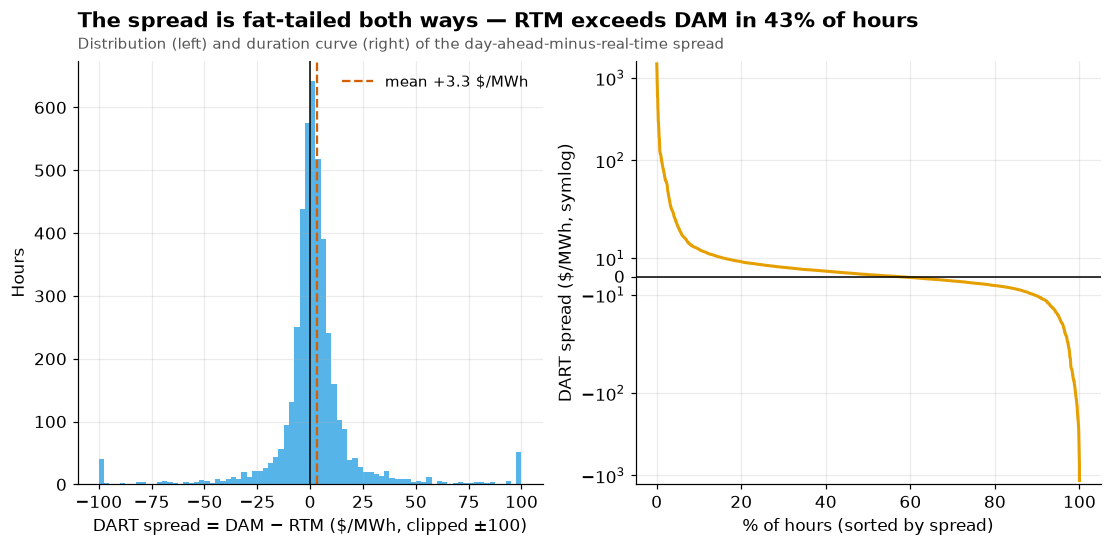

In [5]:
fig = eda.fig17_dam_rtm_spread_dist(panel)

### Interpretation — fig17

The DART spread (day-ahead minus real-time) is centered near \$+3.3/MWh but with heavy tails on **both** sides: real time exceeded day-ahead in **43%** of hours, and the extremes reach hundreds of dollars either way. A symmetric-looking average hides that the *downside* tail (RTM ≫ DAM) is where scarcity lives, and the *upside* tail is where a battery that over-committed day-ahead gets punished. *Business consequence:* the spread's width is the revenue ceiling for arbitrage; its two-sided risk is why the dispatch decision must come from a **distributional** forecast rather than a single expected price.

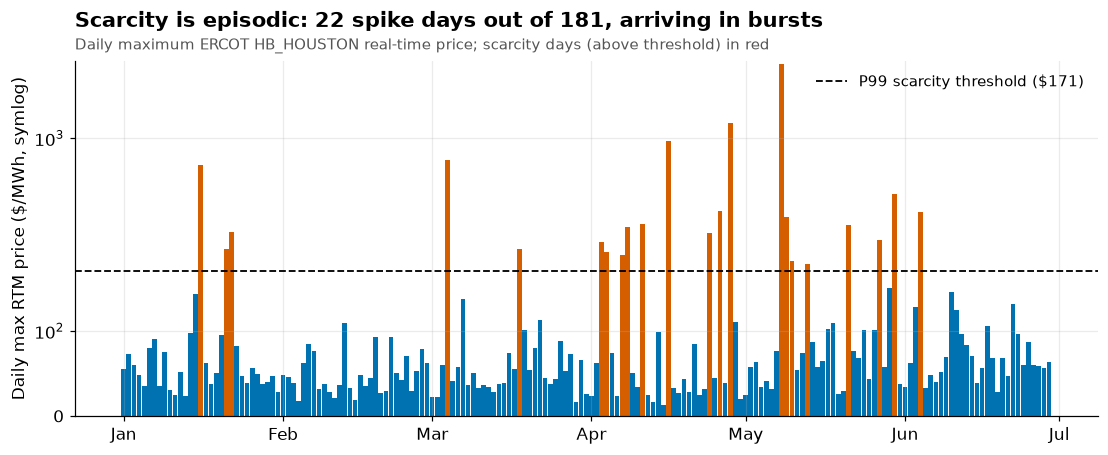

In [6]:
fig = eda.fig18_scarcity_calendar(panel, scarcity_percentile=config['forecast']['scarcity_percentile'])

### Interpretation — fig18

Only **22 days** in the window produced an hour above the P99 scarcity threshold (\$171/MWh) — and they arrive in bursts (consecutive stressed days), not evenly spaced. Long calm stretches punctuated by clustered spikes are the signature of a **regime-driven** market: weather, outages, and net-load stress arrive together. *Business consequence:* (1) a model trained on calm months can silently lose its tail sensitivity — this is why Phase 6 runs a drift monitor with alert thresholds; (2) an operator evaluating this asset should count **paydays per season**, not average daily revenue.

## Takeaways → requirements for the rest of the system

| Fact established here | Requirement it creates |
|---|---|
| 18% of price mass in 1% of hours | Forecast the **tail** (P95), score with **scarcity recall** — Phase 3 |
| Scarcity clusters at hour 20:00 | Battery must **hold charge for the evening window** — Phases 4–5 |
| Spread fat-tailed both ways (43% of hours RTM > DAM) | Dispatch on **quantile forecasts**, settle on realized prices — Phase 5 |
| 22 episodic spike days | **Drift monitoring + human oversight** before real money — Phase 6 |

Next: `02_features_leakage.ipynb` — what the model is allowed to know at forecast time, and the test that proves nothing from the future leaks in.